In [1]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv
from langchain_huggingface import ChatHuggingFace,HuggingFaceEndpoint
from langchain_core.messages.utils import trim_messages,count_tokens_approximately

c:\Coding\Python\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

True

In [3]:
MAX_TOKEN=200


In [4]:
llm=HuggingFaceEndpoint(
    repo_id="openai/gpt-oss-120b",
    task="text-generation"
)

model=ChatHuggingFace(llm=llm)

In [5]:
# def Call_model(state:MessagesState):
#     messages=trim_messages(
#         state['messages'],
#         strategy='last',
#         token_counter=count_tokens_approximately,
#         max_tokens=MAX_TOKEN
#     )
#     print("Current Token Count -> ",count_tokens_approximately(messages=messages))

#     for msg in messages:
#         print(msg.content)
#     response = model.invoke(messages)

#     return{
#         "messages":[response]
#     }

In [6]:
def Call_model(state: MessagesState):
    messages = trim_messages(
        state["messages"],
        strategy="last",
        token_counter=count_tokens_approximately,
        max_tokens=MAX_TOKEN,
    )

    # Print token count
    token_count = count_tokens_approximately(messages)
    print("Current Token Count ->", token_count)

    # Print messages
    print("\nMessages:")
    for msg in messages:
        print(f"{type(msg).__name__}: {msg.content}")

    # Debug
    print("\nType of messages:", type(messages))
    print("Length:", len(messages))

    response = model.invoke(messages)

    return {
        "messages": [response]
    }

In [7]:
# def Call_model(state: MessagesState):
#     messages = trim_messages(
#         state["messages"],
#         strategy="last",
#         token_counter=count_tokens_approximately,
#         max_tokens=MAX_TOKEN,
#     )

#     print(type(messages))
#     print(messages)

#     response = model.invoke(messages)

#     return {"messages": [response]}

In [8]:
builder = StateGraph(MessagesState)

builder.add_node("MODEL", Call_model)
builder.add_edge(START, "MODEL")

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

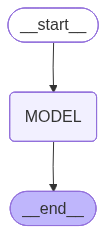

In [9]:
graph

In [15]:
config = {"configurable": {"thread_id": "thread-1"}}
result = graph.invoke(
    {"messages": [{"role": "user", "content": "Hi, my name is Amrit."}]},
    config,
)
result["messages"][-1].content

Current Token Count -> 99

Messages:
HumanMessage: Tell me my name
AIMessage: I don’t actually know your name. If you’d like me to address you by name, feel free to let me know what you’d like to be called!
HumanMessage: Tell me my name
AIMessage: I don’t have any information about your name. If you’d like me to use a particular name or nickname, just let me know!
HumanMessage: Hi, my name is Amrit.

Type of messages: <class 'list'>
Length: 5


'Nice to meet you, Amrit! How can I help you today?'

In [11]:
result = graph.invoke(
    {"messages": [{"role": "user", "content":"I am learning langgraph"}]},
    config,
)
result["messages"][-1].content

Current Token Count -> 41

Messages:
HumanMessage: Hi, my name is Amrit.
AIMessage: Hello Amrit! 👋 Nice to meet you. How can I assist you today?
HumanMessage: I am learning langgraph

Type of messages: <class 'list'>
Length: 3


'Great to hear you’re diving into **LangGraph**! 🎉  \n\nBelow is a quick starter guide that covers the core concepts, a minimal example, and some resources to keep you moving forward.\n\n---\n\n## 1️⃣ What is LangGraph?\n\n- **LangGraph** is a library built on top of LangChain that lets you create **directed‑acyclic graphs (DAGs)** of language‑model components (prompts, tools, agents, memory, etc.).  \n- Think of it as a **flowchart for LLM pipelines**: each node can be a prompt, a function call, a retrieval step, or anything you can invoke, and edges define the order and conditional branching.  \n- The big win: **modular, reusable, and debuggable** workflows that can handle loops, branching, and parallelism without writing a lot of boilerplate.\n\n---\n\n## 2️⃣ Core Building Blocks\n\n| Concept | What it does | Typical type |\n|--------|--------------|--------------|\n| **Node** | A single unit of work (e.g., `PromptNode`, `ToolNode`, `ChainNode`). | `Runnable` / `BaseChain` |\n| **Ed

In [12]:
result = graph.invoke(
    {"messages": [{"role": "user", "content":"Can you explain STM"}]},
    config,
)
result["messages"][-1].content

Current Token Count -> 9

Messages:
HumanMessage: Can you explain STM

Type of messages: <class 'list'>
Length: 1


'**STM** is an abbreviation that pops up in several very different fields. Below is a quick‑tour of the three most common meanings, each with a short “what‑it‑is”, “how it works”, and “why you might care” snapshot. (If you had a different STM in mind, let me know and I’ll dive deeper on that one!)\n\n---\n\n## 1. Software Transactional Memory (STM) – *Concurrency in programming*\n\n| Aspect | What it is | How it works | Why it matters |\n|--------|------------|--------------|----------------|\n| **Domain** | A programming‑language/library technique for coordinating concurrent accesses to shared memory. | • **Transactions** are blocks of code that appear to execute atomically. <br>• The runtime records all reads/writes performed inside a transaction.<br>• At commit time the system checks whether any of the data read has been changed by another thread. <br>• If there’s a conflict, the transaction is **aborted** and automatically **re‑tried** (usually with exponential back‑off). | • Remov

In [16]:
result = graph.invoke(
    {"messages": [{"role": "user", "content":"Tell me my name"}]},
    config,
)
result["messages"][-1].content

Current Token Count -> 125

Messages:
HumanMessage: Tell me my name
AIMessage: I don’t actually know your name. If you’d like me to address you by name, feel free to let me know what you’d like to be called!
HumanMessage: Tell me my name
AIMessage: I don’t have any information about your name. If you’d like me to use a particular name or nickname, just let me know!
HumanMessage: Hi, my name is Amrit.
AIMessage: Nice to meet you, Amrit! How can I help you today?
HumanMessage: Tell me my name

Type of messages: <class 'list'>
Length: 7


'Your name is Amrit.'